## Section 1: Setup and Data Loading

In [2]:
# Todo: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, scipy.stats, and sklearn modules
# Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# From scipy import stats
# From sklearn.model_selection import train_test_split
# From sklearn.linear_model import LinearRegression
# From sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# From sklearn.preprocessing import StandardScaler

# Your code here:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [4]:
try:
    df = pd.read_csv('air_traffic_data.csv')
    print("Data loaded successfully.")
    print(f"Data shape: {df.shape}")
except FileNotFoundError:
    print("File not found. Please ensure 'air_traffic_data.csv' is in the working directory.")
    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Data loaded successfully.
Data shape: (15007, 16)


## 2. Exploratory Data Analysis

In [5]:
print("Dataset Info:", df.info())
print("\nFirst 5 rows:", df.head())
print("\nBasic Statistics:", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15007 entries, 0 to 15006
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Activity Period              15007 non-null  int64 
 1   Operating Airline            15007 non-null  object
 2   Operating Airline IATA Code  14953 non-null  object
 3   Published Airline            15007 non-null  object
 4   Published Airline IATA Code  14953 non-null  object
 5   GEO Summary                  15007 non-null  object
 6   GEO Region                   15007 non-null  object
 7   Activity Type Code           15007 non-null  object
 8   Price Category Code          15007 non-null  object
 9   Terminal                     15007 non-null  object
 10  Boarding Area                15007 non-null  object
 11  Passenger Count              15007 non-null  int64 
 12  Adjusted Activity Type Code  15007 non-null  object
 13  Adjusted Passenger Count     15

In [6]:
print("Missing values:", df.isnull().sum())

Missing values: Activity Period                 0
Operating Airline               0
Operating Airline IATA Code    54
Published Airline               0
Published Airline IATA Code    54
GEO Summary                     0
GEO Region                      0
Activity Type Code              0
Price Category Code             0
Terminal                        0
Boarding Area                   0
Passenger Count                 0
Adjusted Activity Type Code     0
Adjusted Passenger Count        0
Year                            0
Month                           0
dtype: int64


In [10]:
nan_rows = df[df.isna().any(axis=1)]
nan_rows

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,Adjusted Activity Type Code,Adjusted Passenger Count,Year,Month
148,200508,Boeing Company,NaN,Boeing Company,NaN,Domestic,US,Deplaned,Other,Other,Other,18,Deplaned,18,2005,August
6814,201005,Servisair,NaN,Servisair,NaN,Domestic,US,Deplaned,Low Fare,International,G,73,Deplaned,73,2010,May
6815,201005,Servisair,NaN,Servisair,NaN,Domestic,US,Enplaned,Low Fare,International,G,73,Enplaned,73,2010,May
6925,201006,Pacific Aviation,NaN,Pacific Aviation,NaN,International,Europe,Deplaned,Other,International,A,160,Deplaned,160,2010,June
6926,201006,Pacific Aviation,NaN,Pacific Aviation,NaN,International,Europe,Enplaned,Other,International,A,160,Enplaned,160,2010,June
7173,201008,Servisair,NaN,Servisair,NaN,Domestic,US,Deplaned,Low Fare,International,G,118,Deplaned,118,2010,August
7174,201008,Servisair,NaN,Servisair,NaN,Domestic,US,Enplaned,Low Fare,International,G,118,Enplaned,118,2010,August
7747,201101,Servisair,NaN,Servisair,NaN,Domestic,US,Deplaned,Low Fare,International,A,40,Deplaned,40,2011,January
7748,201101,Servisair,NaN,Servisair,NaN,Domestic,US,Enplaned,Low Fare,International,A,40,Enplaned,40,2011,January
7972,201103,Servisair,NaN,Servisair,NaN,Domestic,US,Deplaned,Low Fare,International,A,64,Deplaned,64,2011,March


In [14]:
df[['Operating Airline IATA Code', 'Published Airline IATA Code']].value_counts()

Operating Airline IATA Code  Published Airline IATA Code
UA                           UA                             3046
AS                           AS                              751
OO                           UA                              706
DL                           DL                              386
AC                           AC                              366
                                                            ... 
WO                           WO                                3
5Y                           5Y                                2
EZ                           EZ                                2
XP                           XP                                2
OO                           AS                                2
Name: count, Length: 77, dtype: int64

In [15]:
both_nan = df[df['Operating Airline IATA Code'].isna() & df['Published Airline IATA Code'].isna()]
operating_nan_only = df[df['Operating Airline IATA Code'].isna() & df['Published Airline IATA Code'].notna()]
published_nan_only = df[df['Operating Airline IATA Code'].notna() & df['Published Airline IATA Code'].isna()]

print(f"\n1. Both columns NaN: {len(both_nan)} rows")
print(f"2. Only 'Operating Airline IATA Code' NaN: {len(operating_nan_only)} rows")
print(f"3. Only 'Published Airline IATA Code' NaN: {len(published_nan_only)} rows")


1. Both columns NaN: 54 rows
2. Only 'Operating Airline IATA Code' NaN: 0 rows
3. Only 'Published Airline IATA Code' NaN: 0 rows


In [22]:
df = df.dropna(subset=['Operating Airline IATA Code', 'Published Airline IATA Code'])
print(f"New shape after handling missing values: {df.shape}")

New shape after handling missing values: (14953, 16)


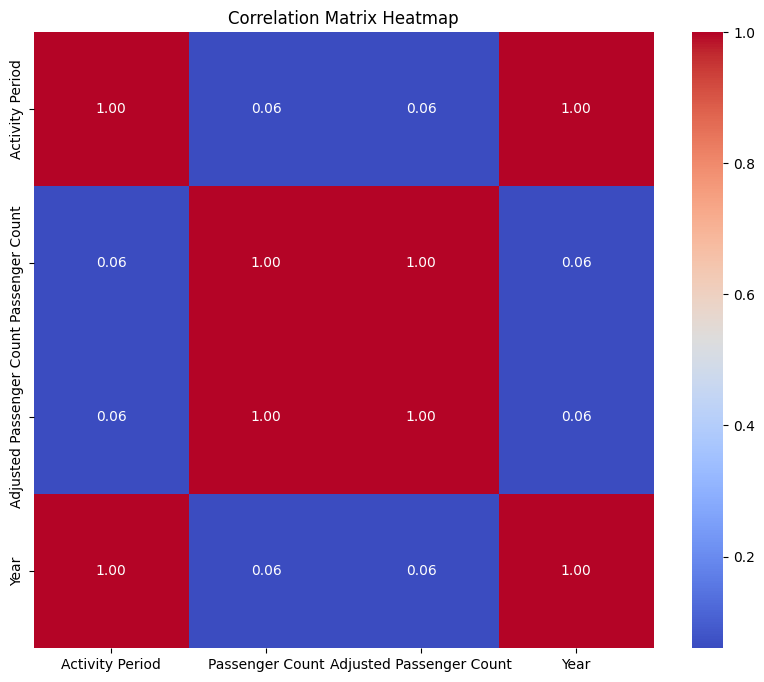

In [21]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

In [23]:
correlation_matrix

,Activity Period,Passenger Count,Adjusted Passenger Count,Year
Activity Period,1.000000,0.061160,0.060188,0.999940
Passenger Count,0.061160,1.000000,0.999941,0.060917
Adjusted Passenger Count,0.060188,0.999941,1.000000,0.059946
Year,0.999940,0.060917,0.059946,1.000000


In [24]:
print("Strongest correlations:", correlation_matrix.unstack().sort_values(ascending=False).drop_duplicates().head(10))

Strongest correlations: Activity Period           Activity Period             1.000000
Passenger Count           Adjusted Passenger Count    0.999941
Activity Period           Year                        0.999940
                          Passenger Count             0.061160
Passenger Count           Year                        0.060917
Activity Period           Adjusted Passenger Count    0.060188
Adjusted Passenger Count  Year                        0.059946
dtype: float64


# Your analysis here:

we have Multicollinearity issues , Activity Period & Year have 0.99994 correlation - They're essentially the same variable. Passenger Count & Adjusted Passenger Count have 0.99994 correlation - These are also essentially the same variable, these variables are causing data leakage

                 Activity Period  Passenger Count  Month_sin  Month_cos
Activity Period          1.00000         0.061160   0.116190   0.013230
Passenger Count          0.06116         1.000000  -0.019229  -0.030801
Month_sin                0.11619        -0.019229   1.000000   0.015684
Month_cos                0.01323        -0.030801   0.015684   1.000000


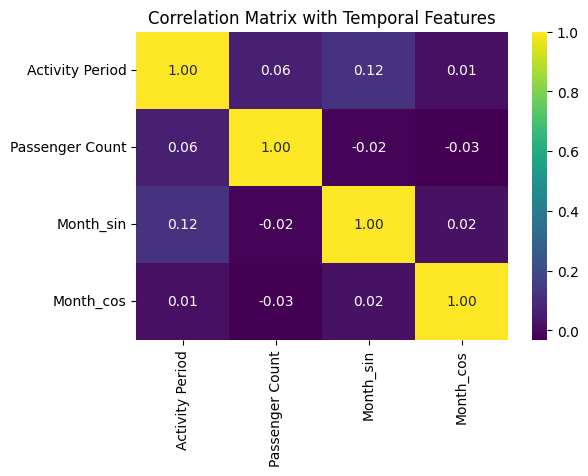

In [26]:
df_clean = df.copy()

df_clean['Month'] = df_clean['Activity Period'].astype(str).str[4:6].astype(int)


df_clean['Month_sin'] = np.sin(2 * np.pi * df_clean['Month']/12)
df_clean['Month_cos'] = np.cos(2 * np.pi * df_clean['Month']/12)

df_clean = df_clean.drop(['Year', 'Adjusted Passenger Count'], axis=1)

corr_clean = df_clean[['Activity Period', 'Passenger Count', 'Month_sin', 'Month_cos']].corr()
print(corr_clean)
plt.figure(figsize=(6, 4))
sns.heatmap(corr_clean, annot=True, fmt=".2f", cmap='viridis')
plt.title("Correlation Matrix with Temporal Features")
plt.show()

we have here all the correlations are low, which indicates the independence between features, r(Activity Period , Month_sin) = 0.116 , slight positive correlation as 'Months_sin' is derived from 'Activity Period', r(Passenger Count ,  temporal features) = 0.03 , very weak correlation as passenger count doesn't strongly depend on time.

## 3. Hypothesis Testing

In [30]:
# FIRST: Check what's actually in 'GEO Summary'
if 'GEO Summary' in df.columns:
    print("Unique values in GEO Summary:")
    print(df['GEO Summary'].value_counts())
    
    # Check if 'Domestic' and 'International' actually exist
    if 'Domestic' in df['GEO Summary'].values and 'International' in df['GEO Summary'].values:
        # CORRECT: Filter by GEO Summary first
        domestic_passengers = df[df['GEO Summary'] == 'Domestic']['Passenger Count'].dropna()
        intl_passengers = df[df['GEO Summary'] == 'International']['Passenger Count'].dropna()
        
        t_stat, p_value = stats.ttest_ind(domestic_passengers, intl_passengers, equal_var=False)
        
        print(f"\nDomestic vs International Passengers:")
        print(f"Domestic samples: {len(domestic_passengers)}")
        print(f"International samples: {len(intl_passengers)}")
        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value: {p_value:.6f}")
        print(f"Mean Domestic: {domestic_passengers.mean():.0f}")
        print(f"Mean International: {intl_passengers.mean():.0f}")
    else:
        print("\n'Domestic' and/or 'International' not found in 'GEO Summary'")
        print("Available categories:", df['GEO Summary'].unique())

Unique values in GEO Summary:
GEO Summary
International    9196
Domestic         5757
Name: count, dtype: int64

Domestic vs International Passengers:
Domestic samples: 5757
International samples: 9196
T-statistic: 42.3628
P-value: 0.000000
Mean Domestic: 58735
Mean International: 10947


In [45]:
print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
freq_map = df['Published Airline'].value_counts(normalize=True).to_dict()
df['Published Airline'] = df['Published Airline'].map(freq_map)
correlation_coef, p_value_corr = stats.pearsonr(df['Passenger Count'], df['Published Airline'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# Interpret the correlation test results
# Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
alpha = 0.05
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    # TODO: Add interpretation about positive/negative correlation
    if correlation_coef > 0:
        print("# TODO: What does positive correlation mean?")
    else:
        print("# TODO: What does negative correlation mean?")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("# TODO: Add your interpretation here")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: -0.0807
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
# TODO: What does negative correlation mean?


## 4. Simple Linear Regression

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

df['Month'] = df['Month'].replace({1: 'January', 2: 'February', 3: 'March', 4: 'April',
                                   5: 'May', 6: 'June', 7: 'July', 8: 'August',
                                   9: 'September', 10: 'October', 11: 'November', 12: 'December'})
# Use actual features that vary per flight/record
# Example: using available columns
features = ['Month', 'GEO Region encoded', 'Terminal encoded']  # You need to encode categoricals

# Encode categorical variables properly first
df_encoded = pd.get_dummies(df, columns=['GEO Region', 'Terminal', 'Boarding Area'], drop_first=True)

# Select features that make sense
# Month might correlate with passenger count (seasonality)
X = df_encoded[['Month']]  # Start with one feature
y = df_encoded['Passenger Count']  # Target: passengers per flight

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f} passengers per flight")

ValueError: could not convert string to float: 'April'

In [41]:
df['Passenger Count'].dtype

dtype('int64')